In [1]:
include("../LiPoSID.jl")
using QuantumOptics
basis = NLevelBasis(2)
using LinearAlgebra
using Plots
using StatsPlots
using Dates
using HDF5

In [2]:
function get_3var_series(file_name, γ)
    h5open(file_name, "r") do file
        ρᵧ = read(file[string(γ)])
        t = ρᵧ["t"]
        ρ₀₀ = ρᵧ["p0"]; Re_ρ₀₁ = ρᵧ["s_re"];  Im_ρ₀₁ = ρᵧ["s_im"]
        var_series = vcat(ρ₀₀', Re_ρ₀₁', Im_ρ₀₁')
        t_series = []
        return(var_series, t_series)
    end
end

get_3var_series (generic function with 1 method)

In [4]:
function var_series_to_density_matrix(var_series)
    ρ₀₀ = var_series[1, :]
    Re_ρ₀₁ = var_series[2, :]
    Im_ρ₀₁ = var_series[3, :]
    
    # Construct density matrices for each time step
    n_steps = length(ρ₀₀)
    ρ_matrices = [zeros(ComplexF64, 2, 2) for _ in 1:n_steps]
    
    for i in 1:n_steps
        ρ_matrices[i][1, 1] = ρ₀₀[i]
        ρ_matrices[i][1, 2] = complex(Re_ρ₀₁[i], Im_ρ₀₁[i])
        ρ_matrices[i][2, 1] = conj(ρ_matrices[i][1, 2])
        ρ_matrices[i][2, 2] = 1 - ρ₀₀[i]
    end
    
    return ρ_matrices
end

var_series_to_density_matrix (generic function with 1 method)

In [30]:
function collect_all_fidelities(data_dir, all_files, γᵢ, basis)
    """
    Compute DMD fidelity for all files and collect into one array.
    
    Returns:
    - all_fidelities: Vector of all fidelity values concatenated
    - fidelities_by_file: Vector of fidelity vectors (one per file)
    """
    fidelities_by_file = []
    all_fidelities = []
    
    for (idx, file_name) in enumerate(all_files)
        try
            # Construct file path
            evol_data_file_name = data_dir * file_name * "_2CUT_data.h5"
            
            # Get variable series
            Y, t = get_3var_series(evol_data_file_name, γᵢ)
            lᵐᵃˣ = size(Y, 2)
            
            # Compute DMD matrix
            Y⁻ = Y[:, 1:end-1]
            Y⁺ = Y[:, 2:end]
            A = Y⁺ * pinv(Y⁻)
            
            # DMD reconstruction
            Yᴰᴹᴰ = Y[:, 1]
            for i in 2:lᵐᵃˣ
                Yᴰᴹᴰ = hcat(Yᴰᴹᴰ, A * Yᴰᴹᴰ[:, end])
            end
            
            # Convert to density matrices and compute fidelity
            ρ = var_series_to_density_matrix(Y)
            ρᴰᴹᴰ = var_series_to_density_matrix(Yᴰᴹᴰ)
            fᴰᴹᴰ = LiPoSID.fidelity_series(basis, ρ, ρᴰᴹᴰ)
            
            # Collect results
            #push!(fidelities_by_file, fᴰᴹᴰ)
            append!(all_fidelities, fᴰᴹᴰ)
            
            #println("Processed $file_name ($(idx)/$(length(all_files)))")
        catch e
            println("Error processing $file_name: $e")
        end
    end
    
    return all_fidelities  #, fidelities_by_file
end

collect_all_fidelities (generic function with 1 method)

In [29]:
parentdir = ".."

data_dir = parentdir*"/DATA/"
println(data_dir)

models_dir = parentdir*"/MODELS/"
tests_dir = parentdir*"/TESTS/"

dodeca_files = ["State_D"*string(n) for n=1:20];
basis_files = ["State_B"*string(n) for n=1:4];

all_files = vcat(dodeca_files, basis_files)
test_files = dodeca_files;

γ_values = [ "0.079477",  "0.25133", "0.79477", "2.5133", "7.9477", "25.133", "79.477", "251.33"];

../DATA/


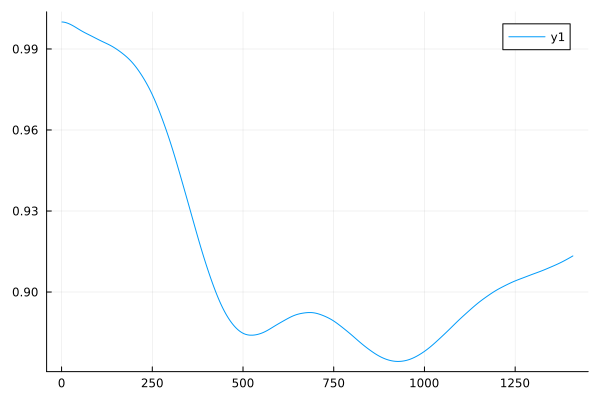

In [62]:
evol_data_file_name = data_dir*dodeca_files[19]*"_2CUT_data.h5"
γᵢ = γ_values[5]
Y, t  = get_3var_series(evol_data_file_name, γᵢ)
lᵐᵃˣ = size(Y, 2)
Y⁻ = Y[:,1:end-1]; Y⁺ = Y[:,2:end]
A = Y⁺ * pinv(Y⁻)
#eigvals, eigvecs = eigen(A)

Yᴰᴹᴰ = Y[:,1]
for i in 2:lᵐᵃˣ
    Yᴰᴹᴰ =hcat(Yᴰᴹᴰ, A * Yᴰᴹᴰ[:, end])
end

ρ = var_series_to_density_matrix(Y)
ρᴰᴹᴰ = var_series_to_density_matrix(Yᴰᴹᴰ)
fᴰᴹᴰ = LiPoSID.fidelity_series(basis, ρ, ρᴰᴹᴰ)
plot(fᴰᴹᴰ)

In [67]:
fidelities_by_gamma = []
infidelities_by_gamma = []

for γᵢ in γ_values 
    f = collect_all_fidelities(data_dir, dodeca_files, γᵢ, basis)
    # Check for invalid fidelity values
    valid_f = filter(x -> 0 <= x <= 1, f)
    invalid_count = length(f) - length(valid_f)
    if invalid_count > 0
        println("Warning: $invalid_count invalid fidelity values (< 0 or > 1) filtered out for γ=$γᵢ")
    end
    push!(fidelities_by_gamma, valid_f)
    push!(infidelities_by_gamma, 1 .- valid_f)
end

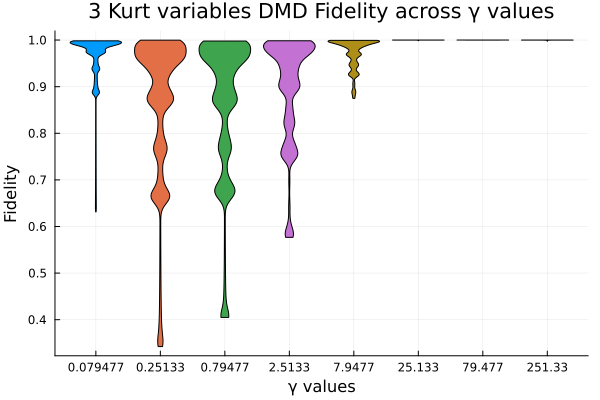

In [74]:
gamma_labels = string.(γ_values)
violin(fidelities_by_gamma, xlabel="γ values", ylabel="Fidelity",  legend=false, title="3 Kurt variables DMD Fidelity across γ values", xticks=(1:length(γ_values), gamma_labels))

In [75]:
savefig("dmd_fidelity_plot.png")

"/home/zah/github/OQSID-thesis/KURT_VARIABLES/dmd_fidelity_plot.png"

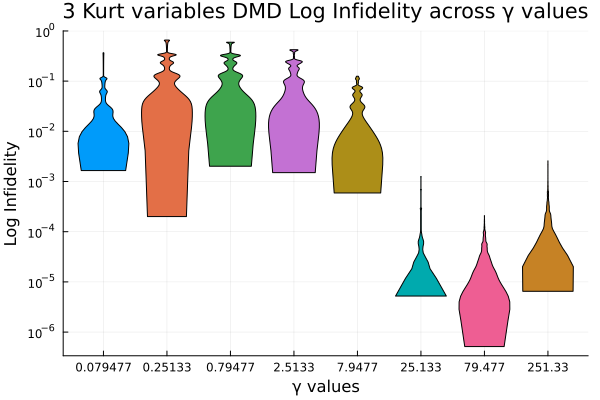

In [76]:
gamma_labels = string.(γ_values)
violin(infidelities_by_gamma, xlabel="γ values", ylabel="Log Infidelity", title="3 Kurt variables DMD Log Infidelity across γ values", xticks=(1:length(γ_values), gamma_labels), yaxis=:log10, legend=false)

In [77]:
savefig("dmd_log_infidelity_plot.png")

"/home/zah/github/OQSID-thesis/KURT_VARIABLES/dmd_log_infidelity_plot.png"